In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv(
    "../data/medical_operations_dashboard_cleaned.csv",
    parse_dates=["Admission_Date", "Discharge_Date"]
)

### **1. Preview the data**

In [3]:
df.head(5)

,patient_id,patient_name,age,gender,blood_group,city,state,contact_number,Admission_Id,Admission_Date,...,Shift,Bed_Id,Ward,Bed_Type,Bed_Status,Bill_Id,Total_Amount,Insurance_Coverage,Paid_Amount,Payment_Status
0,PAT100001,Advik Maharaj,94,Male,O+,Mumbai,Maharashtra,-6958682755,ADM100001,2025-11-07,...,Morning,BED2018,Ortho Ward,General,Cleaning,BILL100001,217621,217621,0,Paid
1,PAT100002,Isaac Dewan,13,Male,B+,Varanasi,Uttar Pradesh,-9831881973,ADM100002,2024-08-15,...,Morning,BED2016,Renal Ward,ICU,Available,BILL100002,137196,82317,54879,Pending
2,PAT100003,Caleb Sami,54,Male,O+,Surat,Gujarat,-6402417919,ADM100003,2025-02-14,...,Morning,BED2012,Ortho Ward,Semi-Private,Occupied,BILL100003,86579,77921,8658,Pending
3,PAT100004,Alexander Chander,64,Male,B+,Patna,Bihar,-8410529099,ADM100004,2025-01-07,...,Night,BED2050,General Ward,ICU,Occupied,BILL100004,15697,7848,7849,Pending
4,PAT100005,Jackson Tiwari,83,Male,B+,Kanpur,Uttar Pradesh,-7801823817,ADM100005,2026-01-17,...,Evening,BED2029,Gastro Ward,Private,Occupied,BILL100005,10976,10976,0,Paid


In [4]:
df.tail(5)

,patient_id,patient_name,age,gender,blood_group,city,state,contact_number,Admission_Id,Admission_Date,...,Shift,Bed_Id,Ward,Bed_Type,Bed_Status,Bill_Id,Total_Amount,Insurance_Coverage,Paid_Amount,Payment_Status
4995,PAT104996,Triya Chopra,85,Female,A+,Gaya,Bihar,-7812216130,ADM104996,2025-10-16,...,Morning,BED2007,Surgical Ward,Semi-Private,Occupied,BILL104996,117726,117726,0,Paid
4996,PAT104997,Jyoti Ganesan,47,Female,O+,Bhubaneswar,Odisha,-6165868819,ADM104997,2025-03-16,...,Morning,BED2048,Pulmonary Ward,Private,Occupied,BILL104997,109071,54535,54536,Pending
4997,PAT104998,Yoshita Wali,16,Female,O+,New Delhi,Delhi,-9909112466,ADM104998,2025-08-16,...,Morning,BED2012,Ortho Ward,Semi-Private,Occupied,BILL104998,131639,92147,39492,Pending
4998,PAT104999,Varsha Dugar,76,Female,A+,Jaipur,Rajasthan,-8051649089,ADM104999,2026-07-25,...,Morning,BED2016,Renal Ward,ICU,Available,BILL104999,56803,51122,5681,Pending
4999,PAT105000,Udarsh Sandal,54,Male,B+,Jamshedpur,Jharkhand,-6791290942,ADM105000,2025-04-12,...,Evening,BED2041,Cancer Ward,General,Reserved,BILL105000,583341,291670,291671,Pending


### **2. Column names**

In [5]:
df.columns

Index(['patient_id', 'patient_name', 'age', 'gender', 'blood_group', 'city',
       'state', 'contact_number', 'Admission_Id', 'Admission_Date',
       'Discharge_Date', 'Diagnosis', 'Treatment', 'Admission_status',
       'Doctor_Id', 'Doctor_Name', 'Specialization', 'Department_Id',
       'Department_Name', 'Staff_Id', 'Staff_Name', 'Role', 'Shift', 'Bed_Id',
       'Ward', 'Bed_Type', 'Bed_Status', 'Bill_Id', 'Total_Amount',
       'Insurance_Coverage', 'Paid_Amount', 'Payment_Status'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   patient_id          5000 non-null   str           
 1   patient_name        5000 non-null   str           
 2   age                 5000 non-null   int64         
 3   gender              5000 non-null   str           
 4   blood_group         5000 non-null   str           
 5   city                5000 non-null   str           
 6   state               5000 non-null   str           
 7   contact_number      5000 non-null   int64         
 8   Admission_Id        5000 non-null   str           
 9   Admission_Date      5000 non-null   datetime64[us]
 10  Discharge_Date      3952 non-null   datetime64[us]
 11  Diagnosis           5000 non-null   str           
 12  Treatment           5000 non-null   str           
 13  Admission_status    5000 non-null   str           
 14  Doc

### **3. Missing values**

In [7]:
df.isnull().sum()

patient_id               0
patient_name             0
age                      0
gender                   0
blood_group              0
city                     0
state                    0
contact_number           0
Admission_Id             0
Admission_Date           0
Discharge_Date        1048
Diagnosis                0
Treatment                0
Admission_status         0
Doctor_Id                0
Doctor_Name              0
Specialization           0
Department_Id            0
Department_Name          0
Staff_Id                 0
Staff_Name               0
Role                     0
Shift                    0
Bed_Id                   0
Ward                     0
Bed_Type                 0
Bed_Status               0
Bill_Id                  0
Total_Amount             0
Insurance_Coverage       0
Paid_Amount              0
Payment_Status           0
dtype: int64

### **4. Duplicate records**

In [8]:
df.duplicated().sum()

np.int64(0)

### **5. Unique values in categorical columns**

In [9]:
df["gender"].unique()


<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

In [10]:
df["Department_Name"].unique()

<ArrowStringArray>
[     'Orthopedics',       'Nephrology', 'General Medicine',
 'Gastroenterology',      'Pulmonology',       'Cardiology',
    'Endocrinology',        'Neurology',         'Oncology',
  'General Surgery']
Length: 10, dtype: str

In [11]:
df['blood_group'].unique()

<ArrowStringArray>
['O+', 'B+', 'A-', 'B-', 'A+', 'AB-', 'AB+', 'O-']
Length: 8, dtype: str

## **Business-Oriented Exploratory Data Analysis**

### **1.Which departments have the highest patient demand?**

In [12]:
department_admissions = (
    df.groupby("Department_Name")
      .size()
      .reset_index(name="Admission_Count")
      .sort_values("Admission_Count", ascending=False)
)

department_admissions

,Department_Name,Admission_Count
3,General Medicine,1309
9,Pulmonology,1001
6,Neurology,518
8,Orthopedics,514
0,Cardiology,451
2,Gastroenterology,273
7,Oncology,246
1,Endocrinology,235
5,Nephrology,231
4,General Surgery,222


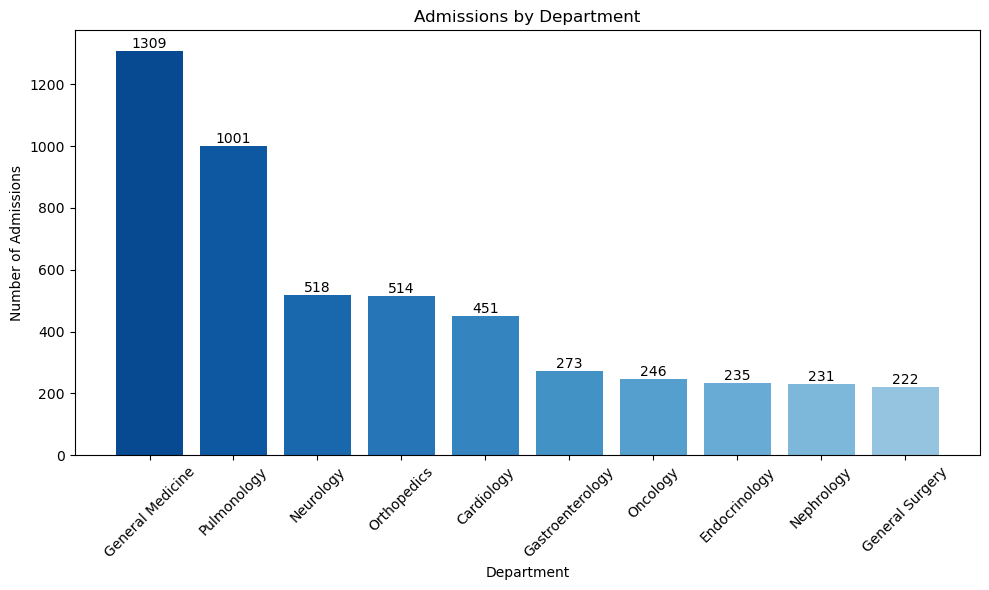

In [13]:
plt.figure(figsize=(10, 6))
colors = plt.cm.Blues(
    np.linspace(0.9, 0.4, len(department_admissions))
)

bars = plt.bar(
    department_admissions["Department_Name"],
    department_admissions["Admission_Count"],
    color=colors
)

plt.title("Admissions by Department")
plt.xlabel("Department")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=45)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### **2.Which treatments are most frequently used across the hospital?**

In [14]:
treatment_counts = (
    df.groupby("Treatment")
      .size()
      .reset_index(name="Treatment_Count")
      .sort_values("Treatment_Count", ascending=False)
)

treatment_counts

,Treatment,Treatment_Count
4,Antibiotic Treatment,284
11,Iron Therapy,275
0,Acid Suppressant Therapy,273
14,Orthopedic Surgery,269
2,Anti-TB Therapy,265
15,Pain Management,264
9,IV Fluid Therapy,257
3,Antibiotic Therapy,255
18,Stroke Management,254
5,Antimalarial Medication,251


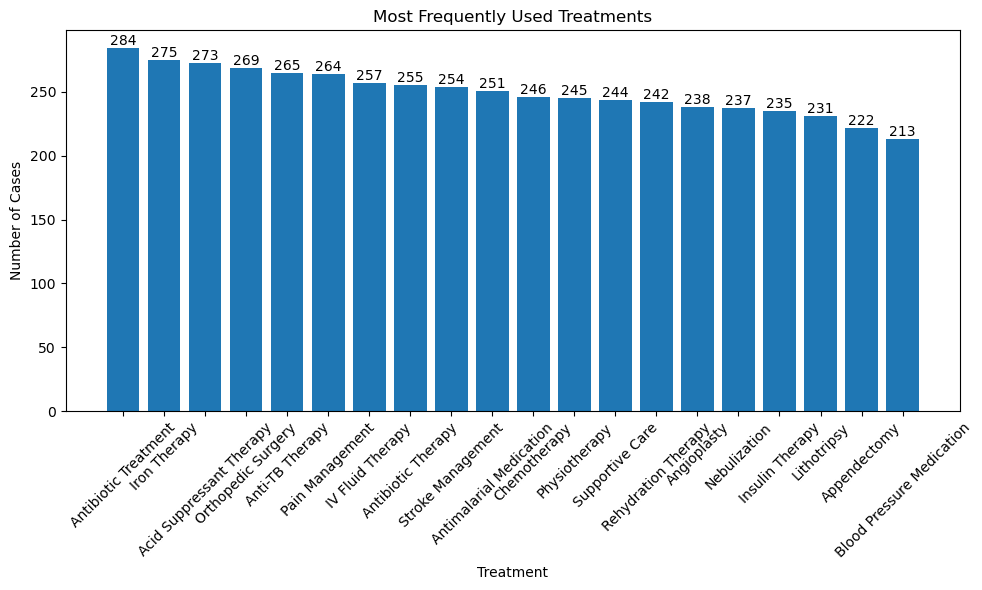

In [15]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    treatment_counts["Treatment"],
    treatment_counts["Treatment_Count"]
)

plt.title("Most Frequently Used Treatments")
plt.xlabel("Treatment")
plt.ylabel("Number of Cases")
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### **3.Which departments have the highest average treatment/billing cost?**

In [16]:
department_cost = (
    df.groupby("Department_Name")["Total_Amount"]
      .mean()
      .reset_index(name="Average_Bill")
      .sort_values("Average_Bill", ascending=False)
)

department_cost

,Department_Name,Average_Bill
7,Oncology,493204.475610
0,Cardiology,186234.549889
6,Neurology,143823.646718
4,General Surgery,118920.297297
8,Orthopedics,106546.492218
5,Nephrology,96064.406926
9,Pulmonology,78330.778222
1,Endocrinology,51718.770213
3,General Medicine,38698.996180
2,Gastroenterology,25464.732601


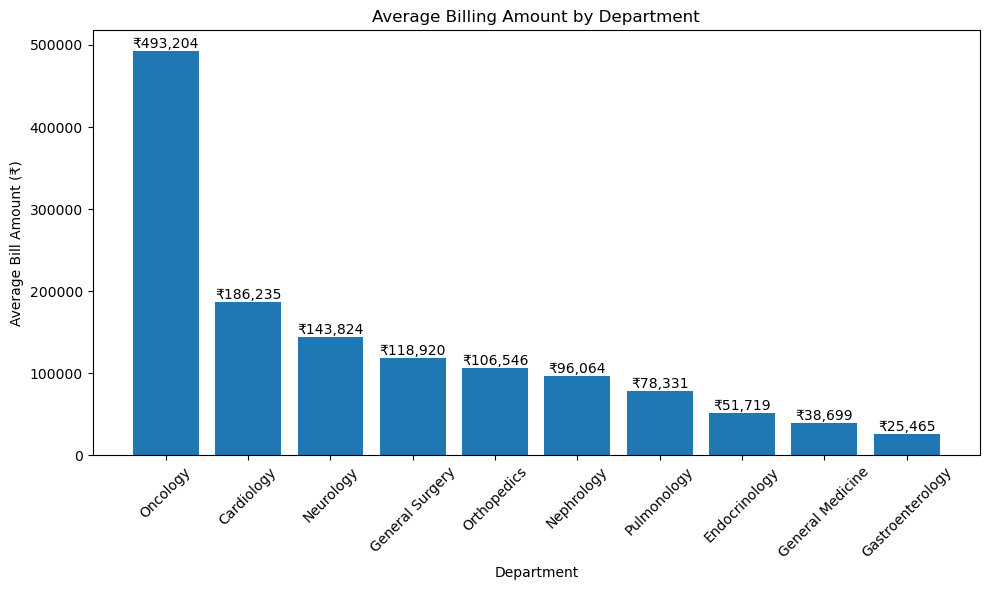

In [17]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    department_cost["Department_Name"],
    department_cost["Average_Bill"]
)

plt.title("Average Billing Amount by Department")
plt.xlabel("Department")
plt.ylabel("Average Bill Amount (₹)")
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"₹{height:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### **4. How much of the patients' total bill is covered by insurance?**

In [18]:
insurance_percentage = (
    df["Insurance_Coverage"].sum()
    / df["Total_Amount"].sum()
) * 100

insurance_percentage

np.float64(77.07067692766745)

In [19]:
total_bills = df["Total_Amount"].sum()
total_insurance = df["Insurance_Coverage"].sum()
total_paid = df["Paid_Amount"].sum()

total_bills, total_insurance, total_paid

(np.int64(531348691), np.int64(409514033), np.int64(121834658))

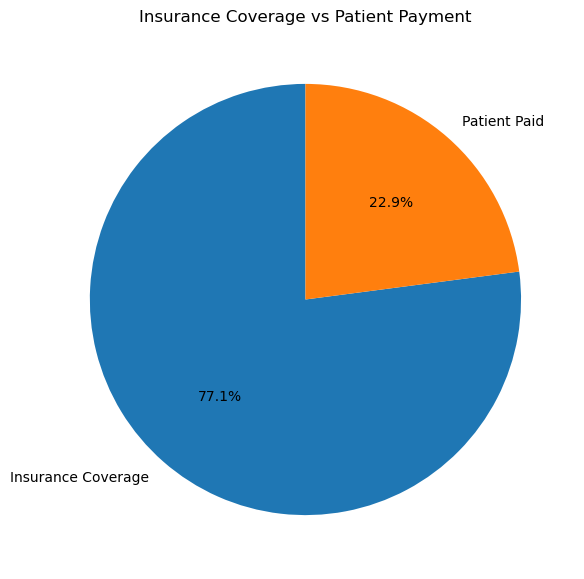

In [20]:
labels = ["Insurance Coverage", "Patient Paid"]
values = [total_insurance, total_paid]

plt.figure(figsize=(7, 7))

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Insurance Coverage vs Patient Payment")
plt.show()

### **5.Payment status distribution**

In [21]:
df["Payment_Status"].value_counts()

Payment_Status
Pending    3965
Paid       1035
Name: count, dtype: int64

In [22]:
payment_status_pct = (
    df["Payment_Status"]
    .value_counts(normalize=True)
    .mul(100)
)

payment_status_pct

Payment_Status
Pending    79.3
Paid       20.7
Name: proportion, dtype: float64

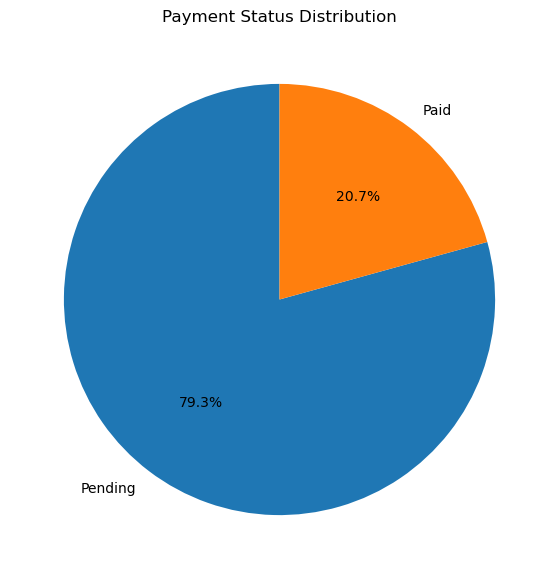

In [23]:
payment_counts = df["Payment_Status"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Payment Status Distribution")
plt.show()

### **6.What is the overall bed-status distribution?**

In [24]:
df["Bed_Status"].value_counts()

Bed_Status
Occupied     2843
Available     937
Cleaning      800
Reserved      420
Name: count, dtype: int64

In [25]:
df["Ward"].value_counts()

Ward
General Ward      1309
Pulmonary Ward    1001
Neuro Ward         518
Ortho Ward         514
Cardiac Ward       451
Gastro Ward        273
Cancer Ward        246
Endocrine Ward     235
Renal Ward         231
Surgical Ward      222
Name: count, dtype: int64

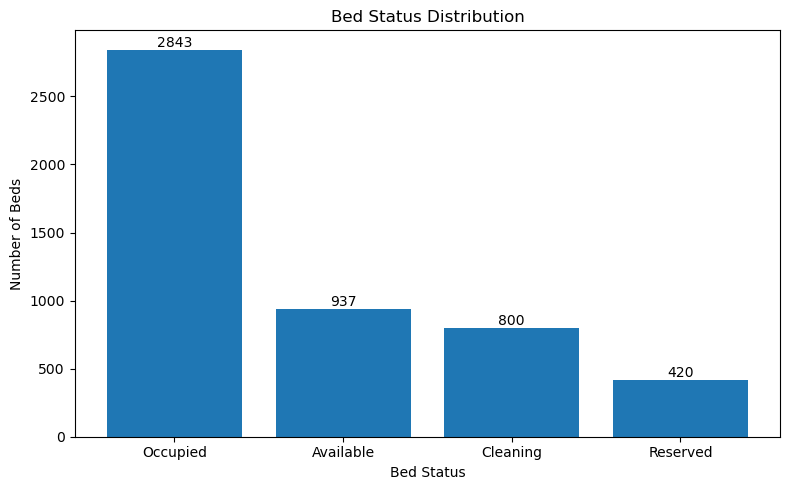

In [26]:
bed_status = df["Bed_Status"].value_counts()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    bed_status.index,
    bed_status.values
)

plt.title("Bed Status Distribution")
plt.xlabel("Bed Status")
plt.ylabel("Number of Beds")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        int(height),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## **INSIGHT**

 - Occupied beds account for 56.86% of the records, while 18.74% are available, 16% are under cleaning, and 8.4% are reserved.

### **7.Which wards have the highest bed occupancy rate?**

In [32]:
bed_utilization = pd.crosstab(
    df["Ward"],
    df["Bed_Status"],
    normalize="index"
) * 100

In [33]:
bed_utilization

Bed_Status,Available,Cleaning,Occupied,Reserved
Ward,,,,
Cancer Ward,22.357724,0.000000,24.390244,53.252033
Cardiac Ward,15.964523,0.000000,69.623060,14.412417
Endocrine Ward,26.808511,22.978723,50.212766,0.000000
Gastro Ward,11.355311,27.106227,61.538462,0.000000
General Ward,0.000000,32.314744,67.685256,0.000000
Neuro Ward,13.899614,14.864865,55.984556,15.250965
Ortho Ward,24.124514,26.070039,49.805447,0.000000
Pulmonary Ward,37.762238,0.000000,62.237762,0.000000
Renal Ward,51.948052,0.000000,0.000000,48.051948


In [34]:
occupied_rate = bed_utilization["Occupied"].sort_values(ascending=False)

occupied_rate

Ward
Cardiac Ward      69.623060
General Ward      67.685256
Pulmonary Ward    62.237762
Gastro Ward       61.538462
Surgical Ward     57.657658
Neuro Ward        55.984556
Endocrine Ward    50.212766
Ortho Ward        49.805447
Cancer Ward       24.390244
Renal Ward         0.000000
Name: Occupied, dtype: float64

Ward
Cardiac Ward      69.623060
General Ward      67.685256
Pulmonary Ward    62.237762
Gastro Ward       61.538462
Surgical Ward     57.657658
Neuro Ward        55.984556
Endocrine Ward    50.212766
Ortho Ward        49.805447
Cancer Ward       24.390244
Renal Ward         0.000000
Name: Occupied, dtype: float64

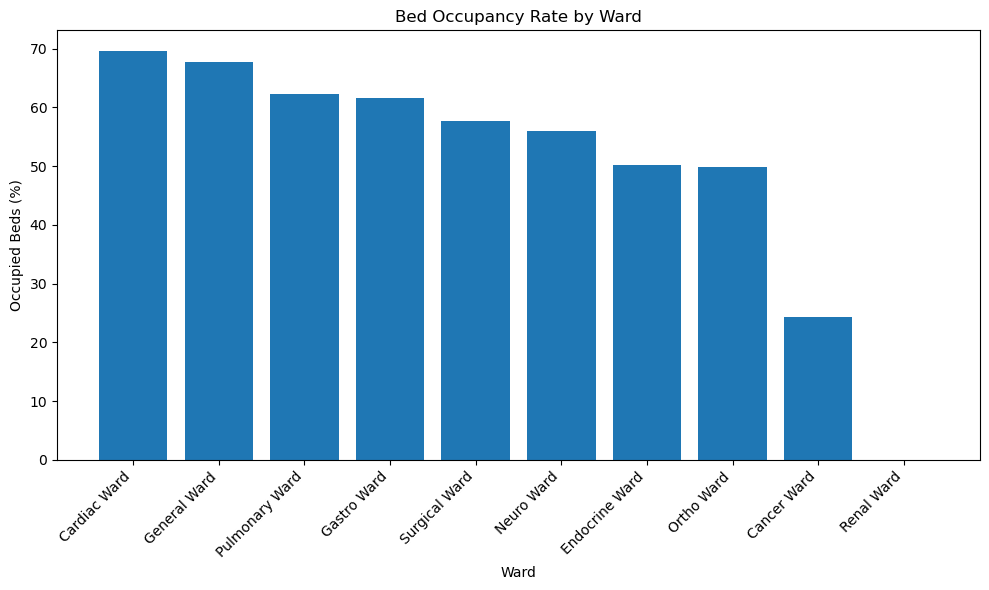

In [36]:
occupied_rate = bed_utilization["Occupied"].sort_values(ascending=False)

plt.figure(figsize=(10, 6))

plt.bar(occupied_rate.index, occupied_rate.values)

plt.title("Bed Occupancy Rate by Ward")
plt.xlabel("Ward")
plt.ylabel("Occupied Beds (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### **8.Which diagnoses generate the highest average bill?**

In [37]:
avg_bill_diagnosis = (
    df.groupby("Diagnosis")["Total_Amount"]
      .mean()
      .sort_values(ascending=False)
)

avg_bill_diagnosis

Diagnosis
Cancer            493204.475610
Heart Attack      318438.197479
Stroke            261720.925197
Fracture          154369.457249
Appendicitis      118920.297297
Tuberculosis       96702.015094
Kidney Stone       96064.406926
COVID-19           86847.114754
Pneumonia          73332.537255
Dengue             57598.373541
Asthma             54399.080169
Arthritis          54038.828571
Diabetes           51718.770213
Malaria            41122.370518
Hypertension       38514.042254
Typhoid            36718.478873
Migraine           30392.174242
Anemia             29470.443636
Food Poisoning     28925.904959
Gastritis          25464.732601
Name: Total_Amount, dtype: float64

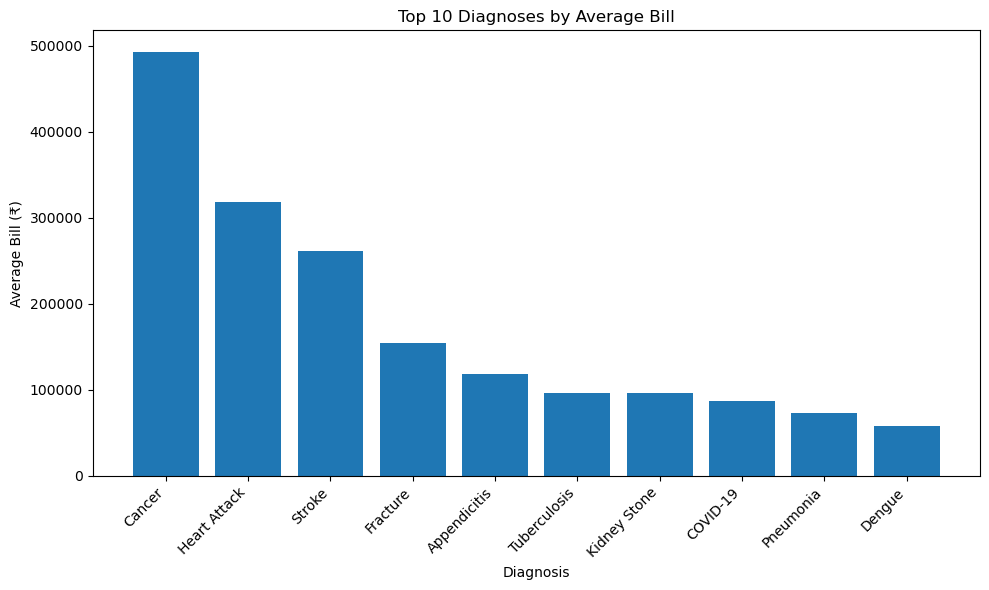

In [38]:
top_10_diagnosis = avg_bill_diagnosis.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_10_diagnosis.index,
    top_10_diagnosis.values
)

plt.title("Top 10 Diagnoses by Average Bill")
plt.xlabel("Diagnosis")
plt.ylabel("Average Bill (₹)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()